# Notebook 04 – Seismic: what time-lapse seismic can and cannot see of a CO₂ layer

After injection stops, what can monitoring confirm about the CO₂? Gauges see the pressure footprint but little of the plume (Notebook 02 §8). Can time-lapse seismic tell how thick a thin CO₂ layer is, and how much CO₂ it holds?

*Time-lapse (4D) seismic* compares surveys before and after injection: CO₂ softens the rock and slows the waves, changing reflection amplitudes and travel times. I follow that chain with textbook rock physics and synthetic traces, then use the singular value decomposition from Computational Mathematics to see what the two measurements can separate. The result depends on how CO₂ and brine mix, and in a 4 m layer the saturation cannot be recovered or told apart from thickness, which matters when surveys are designed.

This notebook covers WP4 and hypothesis H5 of my research proposal (draft v0.6.3). The full monitoring study is proposed future work.

**Labels used in this notebook**

- **My work:** my own earlier work in Seismic (implementations in the practicals, analysis and explanations), summarised in §1.
- **Implemented example:** new code written for this notebook, using textbook physics and illustrative values; it runs here in a few seconds.
- **Proposed adaptation:** what I plan to do in the PhD; not done yet.
- **Evaluated result:** a tested research result. There are none yet.

## 1. My work in Seismic

*Label: My work (my own work in the practicals).*

- **Practical 1, synthetic seismic models:** a wedge model; acoustic impedance (density × P-wave velocity); reflection coefficients; a Ricker wavelet (a standard seismic pulse); convolution to make synthetic traces; and how the wavelet frequency limits what can be resolved. I built the wedge model and the wavelet with the open-source bruges library (see references).
- **Practical 2 and its bonus:** CMP gathers (traces that share a common midpoint between source and receiver), NMO correction (removing the extra travel time at larger offsets), stacking and semblance velocity analysis. The real CMP gather used in the bonus is credited in the practical to Rob Allen (VoilA project).
- **Practical 3 and its bonus:** 3D volumes from SEG-Y files, the standard seismic file format (inlines, crosslines and time slices), and aliasing (the Nyquist rate).
- **Practical 4:** seismic attributes: RMS amplitude, vertical derivatives, coherency and blending.
- **Supervised learning on well logs:** log quality control and facies classification, tested on a blind well (a well kept out of training).

My original practical notebooks and their data are not reproduced in this repository.

## 2. From my work to the CO₂ problem

*Label: proposed adaptation.*

Each method from my work, what it becomes in WP4, and what has to change:

| Method from my work | Use in WP4 | What has to change |
|---|---|---|
| Impedance, reflection coefficients and convolution (Practical 1) | Time-lapse synthetic traces from simulated saturation and pressure (§4) | Rock properties come from rock physics (§3), not from a table, and two surveys are compared |
| Wedge model and wavelet frequency (Practical 1) | A CO₂ layer of growing thickness below the caprock: tuning and the thinnest layer that can be seen (§4) | The layer's velocity depends on the saturation and on how the CO₂ is mixed with brine |
| RMS amplitude (Practical 4) | The amplitude change between surveys in a window at the top of the reservoir (§4) | It is measured as a change between surveys, with noise |
| NMO and velocity analysis (Practical 2) | Time shifts: CO₂ slows the waves, so reflectors below the plume arrive later (§4) | The shift is a measurement of the plume, not a correction to remove |
| SEG-Y and aliasing (Practical 3) | Reading the Sleipner 4D volumes; checking survey sampling | Real data are used for plausibility ranges only, not for a history match (proposal §5) |
| Blind-well test (supervised practical) | The model for testing on unseen realisations (Notebook 02) | The unit held out is a realisation, not a well |
| SVD and conditioning (Computational Mathematics; Notebook 01 §1) | Which combinations of layer properties the data cannot separate (§5) | The sensitivity matrix comes from the rock-physics chain, scaled by noise and prior ranges |

## 3. Rock physics: from CO₂ saturation to P-wave velocity

*Label: implemented example (textbook rock physics; illustrative values for a weak, high-porosity sand).*

How much does CO₂ in the pores slow the P-waves, and does it matter how the CO₂ is mixed with the brine? Gassmann's equation (Gassmann, 1951) gives the bulk modulus (resistance to compression) of a rock filled with a fluid, from the moduli of the dry rock, the mineral and the fluid:

$$K_\text{sat} = K_\text{dry} + \frac{(1 - K_\text{dry}/K_\text{min})^2}{\phi/K_\text{fl} + (1-\phi)/K_\text{min} - K_\text{dry}/K_\text{min}^2}$$

The shear modulus $\mu$ (resistance to shearing) does not depend on the fluid. The P-wave velocity is $V_p = \sqrt{(K_\text{sat} + \tfrac{4}{3}\mu)/\rho}$, with $\rho$ the bulk density.

With brine and CO₂ in the pores, two mixing rules bracket the answer (Mavko et al., 2020):

- **uniform:** brine and CO₂ are finely mixed in every pore. The fluid modulus is the harmonic (Reuss) average, so a little CO₂ makes the whole fluid soft;
- **patchy:** CO₂ sits in patches, each patch obeys Gassmann with its own fluid, and the P-wave moduli of the patches are averaged harmonically.

The values are round numbers for a weak sand, loosely like the Utsira sand at Sleipner: porosity 0.37, quartz grains, brine-saturated $V_p$ about 2050 m/s and $V_s$ about 650 m/s. They are not calibrated to any well.

In [1]:
# import required libraries
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Rock and fluid properties (illustrative)
K_min, rho_min = 36.6e9, 2650.0        # quartz: bulk modulus (Pa), density (kg/m3)
phi = 0.37                             # porosity
K_w, rho_w = 2.5e9, 1040.0             # brine
K_g, rho_g = 0.08e9, 700.0             # CO2 in dense phase

def gassmann(K_dry, K_fl):
    # Bulk modulus of the rock filled with a fluid of modulus K_fl
    return K_dry + (1 - K_dry / K_min)**2 / (phi / K_fl + (1 - phi) / K_min - K_dry / K_min**2)

In [3]:
# Step 1: choose the dry-rock moduli so that the brine-filled rock has Vp = 2050 m/s and Vs = 650 m/s
rho_b = (1 - phi) * rho_min + phi * rho_w
mu_dry = rho_b * 650**2                              # shear modulus from Vs
Ksat_target = rho_b * 2050**2 - 4 / 3 * mu_dry        # bulk modulus the brine-filled rock must have

# Step 2: find K_dry by bisection, running Gassmann's equation backwards
lo, hi = 0.1e9, Ksat_target
for _ in range(200):
    mid = 0.5 * (lo + hi)
    lo, hi = (mid, hi) if gassmann(mid, K_w) < Ksat_target else (lo, mid)
K_dry = 0.5 * (lo + hi)
print(f'dry-rock bulk modulus {K_dry / 1e9:.2f} GPa, shear modulus {mu_dry / 1e9:.2f} GPa')

dry-rock bulk modulus 2.02 GPa, shear modulus 0.87 GPa


In [4]:
def density(Sg):
    return (1 - phi) * rho_min + phi * ((1 - Sg) * rho_w + Sg * rho_g)

def vp_uniform(Sg):
    # fine mixing: harmonic average of the fluid moduli, then Gassmann
    K_fl = 1 / ((1 - Sg) / K_w + Sg / K_g)
    return np.sqrt((gassmann(K_dry, K_fl) + 4 / 3 * mu_dry) / density(Sg))

def vp_patchy(Sg):
    # patches: Gassmann for each fluid, then harmonic average of the P-wave moduli
    M_w = gassmann(K_dry, K_w) + 4 / 3 * mu_dry
    M_g = gassmann(K_dry, K_g) + 4 / 3 * mu_dry
    M = 1 / ((1 - Sg) / M_w + Sg / M_g)
    return np.sqrt(M / density(Sg))

vb = vp_uniform(0.0)      # brine-filled baseline
for Sg in [0.0, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8]:
    print(f'Sg = {Sg:.2f}: Vp uniform {vp_uniform(Sg):6.0f} m/s ({1 - vp_uniform(Sg) / vb:5.1%} drop), '
          f'Vp patchy {vp_patchy(Sg):6.0f} m/s ({1 - vp_patchy(Sg) / vb:5.1%} drop)')

Sg = 0.00: Vp uniform   2050 m/s ( 0.0% drop), Vp patchy   2050 m/s ( 0.0% drop)
Sg = 0.05: Vp uniform   1636 m/s (20.2% drop), Vp patchy   1978 m/s ( 3.5% drop)
Sg = 0.10: Vp uniform   1508 m/s (26.5% drop), Vp patchy   1913 m/s ( 6.7% drop)
Sg = 0.20: Vp uniform   1408 m/s (31.3% drop), Vp patchy   1801 m/s (12.1% drop)
Sg = 0.30: Vp uniform   1368 m/s (33.3% drop), Vp patchy   1708 m/s (16.7% drop)
Sg = 0.50: Vp uniform   1336 m/s (34.8% drop), Vp patchy   1561 m/s (23.9% drop)
Sg = 0.80: Vp uniform   1323 m/s (35.5% drop), Vp patchy   1402 m/s (31.6% drop)


In [5]:
# Known-answer checks: with only brine or only CO2 in the pores the two mixing rules must agree
print(f'Sg = 0: uniform {vp_uniform(0.0):.3f} m/s, patchy {vp_patchy(0.0):.3f} m/s')
print(f'Sg = 1: uniform {vp_uniform(1.0):.3f} m/s, patchy {vp_patchy(1.0):.3f} m/s')

Sg = 0: uniform 2050.000 m/s, patchy 2050.000 m/s
Sg = 1: uniform 1322.682 m/s, patchy 1322.682 m/s


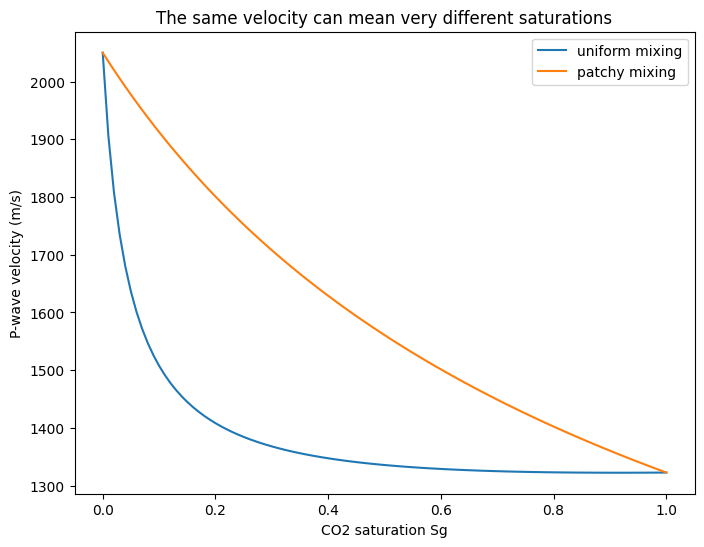

In [6]:
# Plot Vp against CO2 saturation for both mixing rules
Sg_grid = np.linspace(0, 1, 101)
plt.figure(figsize=(8, 6))
plt.plot(Sg_grid, vp_uniform(Sg_grid), label='uniform mixing')
plt.plot(Sg_grid, vp_patchy(Sg_grid), label='patchy mixing')
plt.xlabel('CO2 saturation Sg')
plt.ylabel('P-wave velocity (m/s)')
plt.title('The same velocity can mean very different saturations')
plt.legend();

#### How to read this result:

- With uniform mixing, $V_p$ falls by 31 % at a saturation of only 0.2 and hardly changes after that (35.5 % at 0.8): once a little CO₂ is in every pore, the fluid is already soft.
- With patchy mixing the fall is gradual: 12 % at 0.2 and 32 % at 0.8.
- The two rules agree exactly with only brine or only CO₂ in the pores, as they must.

A velocity drop of 30 % therefore means a saturation between 0.1 and 0.2 with uniform mixing, but between 0.5 and 0.8 with patchy mixing. So the mixing rule is a modelling choice that belongs in $e_\text{obs}$, the observation-model error of the proposal's error budget (proposal §7), and it is one reason why monitoring results depend on the assumed rock physics (Gahlot et al., 2025).

### 3.1 Pressure also changes the rock

*Label: proposed adaptation (concept only; not implemented here).*

Injection raises the pore pressure and lowers the effective stress (roughly, the overburden stress minus the pore pressure: the load carried by the grains), which softens the dry rock, so the velocity falls even where there is no CO₂. After shut-in the pressure falls back while the CO₂ stays, so the two effects separate in time. Landrø (2001) separated pressure and saturation changes using amplitudes at near and far offsets; at Snøhvit the pressure effect dominated except near the well (Grude et al., 2013). In WP4 the dry-rock moduli will depend on effective stress through a relation fitted to published data for the chosen site, and pressure will enter the chain above through $K_\text{dry}$ and $\mu_\text{dry}$.

## 4. A thin CO₂ layer: amplitude, tuning and time shift

*Label: implemented example (normal-incidence synthetic traces).*

Can a thin CO₂ layer below the caprock be seen in time-lapse seismic, and which measurement tells its thickness? I make synthetic traces at normal incidence (waves travelling straight down and back up) by convolution, for a layered model that reuses the wedge idea from Practical 1. A shale caprock ($V_p$ 2300 m/s, density 2300 kg/m³) lies down to 100 m, above an 80 m sand. In the monitor survey CO₂ with saturation 0.3 (uniform mixing) fills the top $h$ metres of the sand. For each boundary:

1. the reflection coefficient is $(Z_2 - Z_1)/(Z_2 + Z_1)$, with $Z$ the acoustic impedance, as in Practical 1;
2. a 30 Hz Ricker wavelet (Ricker, 1953) is placed at the two-way time of the boundary, scaled by the coefficient. This is the convolution of Practical 1, written out so that reflection times are not rounded to samples.

Two time-lapse measurements are taken from the monitor and baseline traces:

- the **RMS amplitude** (root-mean-square amplitude, Practical 4's attribute) in a 50 ms window around the top of the sand, as a change relative to the baseline survey;
- the **time shift** of reflectors below the sand: they arrive later by $2h(1/V_\text{CO₂ sand} - 1/V_\text{brine sand})$.

In [7]:
# Caprock values and time axis (two-way time, 0.2 ms sampling)
Vp_sh, rho_sh = 2300.0, 2300.0
tt = np.arange(0, 0.30, 0.0002)

def ricker(t, f=30.0):
    # Ricker wavelet with peak frequency f (Hz), centred on t = 0
    a = (np.pi * f * t)**2
    return (1 - 2 * a) * np.exp(-a)

def boundaries(h, Sg, z_top=100.0, sand=80.0):
    # Two-way times and reflection coefficients: shale / CO2 sand (h m) / brine sand / shale
    Z_sh = Vp_sh * rho_sh
    Z_b = vp_uniform(0.0) * density(0.0)                 # brine sand
    Z_g = vp_uniform(Sg) * density(Sg)                   # CO2 sand
    t_top = 2 * z_top / Vp_sh
    if h <= 0:                                           # baseline: no CO2 layer
        return [(t_top, (Z_b - Z_sh) / (Z_b + Z_sh)),
                (t_top + 2 * sand / vp_uniform(0.0), (Z_sh - Z_b) / (Z_sh + Z_b))]
    t_mid = t_top + 2 * h / vp_uniform(Sg)
    return [(t_top, (Z_g - Z_sh) / (Z_g + Z_sh)),
            (t_mid, (Z_b - Z_g) / (Z_b + Z_g)),
            (t_mid + 2 * (sand - h) / vp_uniform(0.0), (Z_sh - Z_b) / (Z_sh + Z_b))]

def trace(h, Sg):
    # Synthetic trace: one scaled wavelet at every boundary
    return sum(rc * ricker(tt - t0) for t0, rc in boundaries(h, Sg))

In [8]:
# Calculating the two time-lapse measurements for a CO2 layer of thickness h and saturation Sg
t_top = 2 * 100.0 / Vp_sh
window = (tt > t_top - 0.02) & (tt < t_top + 0.03)      # 50 ms window around the top of the sand

def rms(x):
    return np.sqrt(np.mean(x[window]**2))

rms_base = rms(trace(0, 0))

def measurements(h, Sg):
    # relative RMS amplitude change, and time shift below the sand in ms
    amp = rms(trace(h, Sg)) / rms_base - 1
    shift = 2 * h * (1 / vp_uniform(Sg) - 1 / vp_uniform(0.0)) * 1000
    return np.array([amp, shift])

for h in [0, 2, 4, 6, 8, 10, 12, 15, 20, 30]:
    amp, shift = measurements(h, 0.3)
    print(f'h = {h:2d} m: RMS amplitude change {amp:+.2f} (x baseline), time shift {shift:5.2f} ms')
print(f'quarter wavelength in the CO2 sand at 30 Hz: {vp_uniform(0.3) / 30 / 4:.1f} m')

h =  0 m: RMS amplitude change +0.00 (x baseline), time shift  0.00 ms
h =  2 m: RMS amplitude change +0.65 (x baseline), time shift  0.97 ms
h =  4 m: RMS amplitude change +1.71 (x baseline), time shift  1.95 ms
h =  6 m: RMS amplitude change +2.55 (x baseline), time shift  2.92 ms
h =  8 m: RMS amplitude change +3.03 (x baseline), time shift  3.89 ms
h = 10 m: RMS amplitude change +3.15 (x baseline), time shift  4.86 ms
h = 12 m: RMS amplitude change +2.98 (x baseline), time shift  5.84 ms
h = 15 m: RMS amplitude change +2.51 (x baseline), time shift  7.30 ms
h = 20 m: RMS amplitude change +1.91 (x baseline), time shift  9.73 ms
h = 30 m: RMS amplitude change +1.79 (x baseline), time shift 14.59 ms
quarter wavelength in the CO2 sand at 30 Hz: 11.4 m


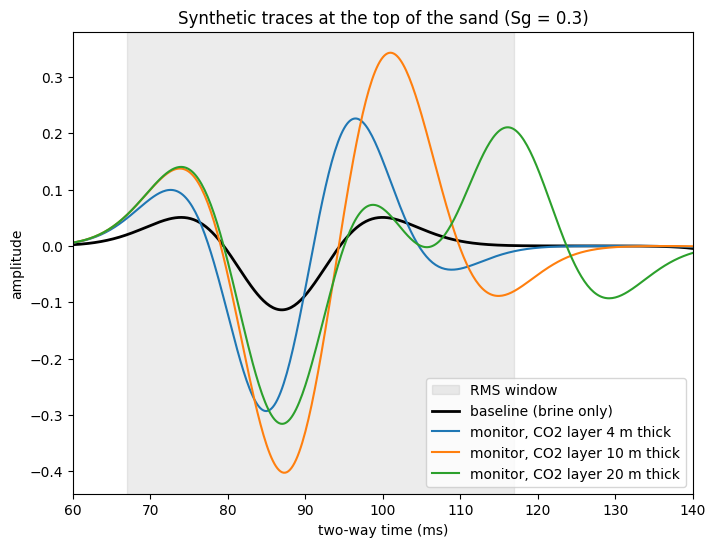

In [9]:
# Plot the baseline trace and three monitor traces around the top of the sand
plt.figure(figsize=(8, 6))
plt.axvspan((t_top - 0.02) * 1000, (t_top + 0.03) * 1000, color='grey', alpha=0.15, label='RMS window')
plt.plot(tt * 1000, trace(0, 0), 'k', lw=2, label='baseline (brine only)')
for h in [4, 10, 20]:
    plt.plot(tt * 1000, trace(h, 0.3), label=f'monitor, CO2 layer {h} m thick')
plt.xlim(60, 140)
plt.xlabel('two-way time (ms)')
plt.ylabel('amplitude')
plt.title('Synthetic traces at the top of the sand (Sg = 0.3)')
plt.legend();

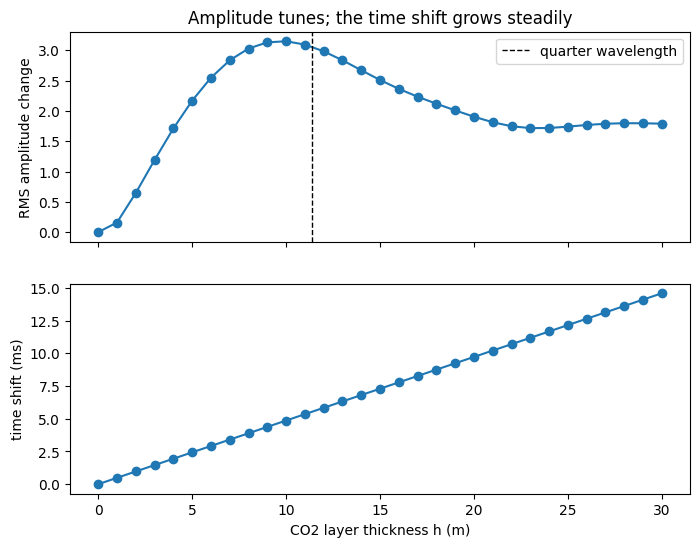

In [10]:
# Plot the tuning curve and the time shift against layer thickness
h_grid = np.arange(0, 31, 1.0)
obs = np.array([measurements(h, 0.3) for h in h_grid])

fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
ax[0].plot(h_grid, obs[:, 0], 'o-')
ax[0].axvline(vp_uniform(0.3) / 120, color='k', ls='--', lw=1, label='quarter wavelength')
ax[0].set_ylabel('RMS amplitude change')
ax[0].legend()
ax[1].plot(h_grid, obs[:, 1], 'o-')
ax[1].set_ylabel('time shift (ms)')
ax[1].set_xlabel('CO2 layer thickness h (m)')
ax[0].set_title('Amplitude tunes; the time shift grows steadily');

#### How to read this result:

- In the traces, CO₂ turns the weak baseline trough at the top of the sand into a strong one, because the CO₂ sand has a much lower impedance than the shale above it. The base of the CO₂ layer gives a peak. For the 4 m layer the two overlap into one wavelet; for the 20 m layer they are separate.
- The RMS amplitude change grows with thickness up to about 10 m, where the RMS amplitude has risen by 3.15 times its baseline value, and then falls back: this is **tuning**, the interference of the reflections from the top and the base of a thin layer. The peak is close to a quarter of the wavelength in the CO₂ sand, 11.4 m (Widess, 1973). Below that thickness a thin layer with much CO₂ and a thicker layer with less can give the same amplitude.
- Beyond about 20 m the peak from the base of the layer leaves the 50 ms window (grey band), so the curve levels off at the value of the top reflection alone. The window is part of how the measurement is defined.
- The time shift grows in a straight line, 0.486 ms per metre of CO₂ layer at this saturation. Even a 2 m layer gives about 1 ms, twice the 0.5 ms noise assumed in §5.

The two measurements therefore respond to the layer in different ways: the amplitude change peaks near the tuning thickness, while the time shift keeps growing. So they are used together, and the next section asks what the pair can separate.

## 5. What the two measurements can separate: singular values

*Label: implemented example (local sensitivity, using SVD from Computational Mathematics).*

From the amplitude change and the time shift together, can both the thickness and the saturation of the layer be recovered? I answer this with a local sensitivity analysis. For a layer with thickness $h$ and saturation $S_g$, the sensitivity (Jacobian) matrix $J$ holds the change of each measurement per change of each property, computed by central differences. Before the SVD:

- each column is multiplied by the prior range of its property, the range thought plausible before any data (20 m for $h$, 0.7 for $S_g$), so both properties are on the same footing;
- each row is divided by the noise of its measurement (5 % for the amplitude, 0.5 ms for the time shift), so that 1 means "one noise level".

The SVD $J = U \Sigma V^T$ then gives the combinations of $h$ and $S_g$ the data constrain well (large singular value) and badly (small singular value). The condition number is the ratio of the two. The last row of $V^T$ is the **weakest direction**: the combination of $h$ and $S_g$ that the data see least.

Because of the scaling, a singular value below 1 means that, to first order, moving across the whole prior range in that direction changes the data by less than one noise level: the data cannot see that direction at all.

In [11]:
noise = np.array([0.05, 0.5])            # amplitude (relative), time shift (ms)
prior_range = np.array([20.0, 0.7])      # thickness (m), saturation

for h0, S0 in [(4, 0.3), (10, 0.3), (20, 0.3), (4, 0.1), (10, 0.1), (10, 0.6)]:
    # Step 1: sensitivity matrix by central differences
    J = np.zeros((2, 2))
    J[:, 0] = (measurements(h0 + 0.1, S0) - measurements(h0 - 0.1, S0)) / 0.2
    J[:, 1] = (measurements(h0, S0 + 0.005) - measurements(h0, S0 - 0.005)) / 0.01
    # Step 2: scale by prior ranges (columns) and noise (rows)
    J_scaled = J * prior_range[None, :] / noise[:, None]
    # Step 3: SVD
    U, s, Vt = np.linalg.svd(J_scaled)
    print(f'h = {h0:2d} m, Sg = {S0:.1f}: singular values {s[0]:7.2f} and {s[1]:6.3f}, condition number {s[0] / s[1]:6.1f}, '
          f'weakest direction (h, Sg) = ({Vt[1, 0]:+.2f}, {Vt[1, 1]:+.2f})')

h =  4 m, Sg = 0.3: singular values  199.50 and  0.486, condition number  410.5, weakest direction (h, Sg) = (+0.11, -0.99)
h = 10 m, Sg = 0.3: singular values   27.74 and 19.706, condition number    1.4, weakest direction (h, Sg) = (-0.92, -0.39)
h = 20 m, Sg = 0.3: singular values   44.94 and 12.216, condition number    3.7, weakest direction (h, Sg) = (+0.16, +0.99)
h =  4 m, Sg = 0.1: singular values  167.16 and  0.308, condition number  541.9, weakest direction (h, Sg) = (+0.53, -0.85)
h = 10 m, Sg = 0.1: singular values  131.59 and 11.367, condition number   11.6, weakest direction (h, Sg) = (+0.99, -0.13)
h = 10 m, Sg = 0.6: singular values   29.04 and  7.816, condition number    3.7, weakest direction (h, Sg) = (+0.22, +0.97)


#### How to read this result:

- **In a thin layer (4 m)** the smallest singular values are 0.486 ($S_g$ = 0.3) and 0.308 ($S_g$ = 0.1), both below 1, and the condition numbers are 410 and 542. At $S_g$ = 0.3 the weakest direction is almost pure saturation (−0.99): with uniform mixing the velocity hardly changes above a saturation of about 0.2 (§3), so neither measurement sees how much CO₂ there is. At $S_g$ = 0.1 the weakest direction mixes the two: a thicker layer with less CO₂ looks like a thinner layer with more.
- **Near tuning thickness (10 m, $S_g$ = 0.3)** both singular values are large (27.7 and 19.7) and the condition number is 1.4: amplitude and time shift respond to thickness and saturation in different ways, so both can be recovered.
- **In the other cases** the smallest singular value lies between 7.8 and 12.2, so the weaker direction is still seen, at about 8 to 12 noise levels across the prior. Saturation is the weaker direction at 20 m and at $S_g$ = 0.6; thickness is the weaker one at 10 m with $S_g$ = 0.1, because at low saturation the velocity is very sensitive to saturation. The 20 m case needs care: the base of the layer sits at the edge of the RMS window (§4), so the window choice affects its amplitude sensitivity.

These results agree with the second half of hypothesis H5, that time-lapse seismic constrains thin layers only weakly. They are local results, at single points, with uniform mixing and no pressure effect.

For monitoring, this means that in a 4 m layer the saturation, or the trade-off between thickness and saturation, is invisible to these two measurements: they cannot be relied on to show how much CO₂ a thin layer holds. WP4 repeats the analysis across the prior and then asks the global question by ensemble inversion with the surrogate.

## 6. How WP4 will be evaluated

*Label: proposed adaptation. Values in square brackets are set with the supervisor before any results exist.*

The examples of §§3–5 become tasks with checks for the monitoring study:

| Task | How it is checked |
|---|---|
| Rock-physics chain | Known answers first: the mixing rules agree for brine only and CO₂ only (§3); a monitor survey with no CO₂ gives no change (§4, h = 0) |
| Pressure gauges | Noise and drift added to simulated pressures; the wrong-boundary alarm of Notebook 02 §8, with its threshold set on calibration cases |
| Local identifiability | Singular values at points across the prior, for each mixing rule (§5) |
| Ensemble inversion | Inversion with the surrogate, checked against inversion with the reference on a subset of [20] realisations |
| Value of information | Expected improvement in the Case A–C decisions from gauges, from seismic, and from both |
| Plausibility | Amplitude changes and time shifts compared with the ranges seen in the Sleipner 4D data; not a history match |

The output of WP4 is $e_\text{obs}$ (the effect of rock-physics and noise choices) and a tested map of which data constrain which quantities (hypothesis H5; proposal §6).

## 7. Assumptions and what has to change

- The traces are 1D, at normal incidence, with a fixed wavelet and no noise in the traces themselves. Convolutional synthetics like these give upper bounds on detectability (proposal §11).
- The rock values are illustrative. Gassmann's equation assumes low frequency and connected pores, and the dry-rock moduli will depend on effective stress (§3.1).
- The sensitivity matrix is local. Global questions, such as whether a wrong boundary can be detected, need the ensemble (WP4).
- The time shift assumes the whole velocity change sits in the CO₂ layer. With pressure effects the rock outside the plume changes too.

## 8. Status

**Run here:** the implemented examples of §§3–5: Gassmann with two mixing rules, synthetic traces with tuning and time shift, and singular values. **Proposed for the PhD:** the pressure sensitivity of the dry rock (§3.1, concept only), gauges with drift, ensemble inversion and the value of information (§6). **My work:** summarised in §1. **Research results:** none yet.

## References and further reading

- Agile Scientific. bruges: bag of really useful geoscience equations and stuff (Python library, Apache-2.0 licence). https://github.com/agilescientific/bruges (used in my Practical 1, §1).
- Gahlot, A. P., Erdinc, H. T. & Herrmann, F. J. (2025). Sensitivity-aware rock physics enhanced digital shadow for underground-energy storage monitoring. arXiv:2504.14405. (Gahlot et al., 2025b in the proposal.)
- Gassmann, F. (1951). Über die Elastizität poröser Medien. *Vierteljahrsschrift der Naturforschenden Gesellschaft in Zürich* 96, 1–23.
- Grude, S., Landrø, M. & Osdal, B. (2013). Time-lapse pressure–saturation discrimination for CO₂ storage at the Snøhvit field. *International Journal of Greenhouse Gas Control* 19, 369–378.
- Landrø, M. (2001). Discrimination between pressure and fluid saturation changes from time-lapse seismic data. *Geophysics* 66(3), 836–844.
- Mavko, G., Mukerji, T. & Dvorkin, J. (2020). *The Rock Physics Handbook*, 3rd edition. Cambridge University Press.
- Ricker, N. (1953). The form and laws of propagation of seismic wavelets. *Geophysics* 18(1), 10–40.
- Widess, M. B. (1973). How thin is a thin bed? *Geophysics* 38(6), 1176–1180.